In [1]:
import sys

print(sys.executable)

C:\Users\tyuce\anaconda3\envs\spytrader\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
spy = yf.download(
    "SPY",
    start="1993-01-29",
    auto_adjust=False,
    progress=False
)

In [4]:
spy.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
1993-01-29,24.113256,43.93750,43.96875,43.75000,43.96875,1003200
1993-02-01,24.284769,44.25000,44.25000,43.96875,43.96875,480500
1993-02-02,24.336218,44.34375,44.37500,44.12500,44.21875,201300
1993-02-03,24.593472,44.81250,44.84375,44.37500,44.40625,529400
1993-02-04,24.696379,45.00000,45.09375,44.46875,44.96875,531500


In [5]:
spy.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2026-08-21,765.719971,765.719971,767.849976,764.169983,766.049988,39188700
2026-08-24,763.469971,763.469971,765.219971,762.080017,764.780029,32430900
2026-08-25,765.909973,765.909973,766.780029,763.049988,766.159973,27422300
2026-08-26,766.080017,766.080017,767.349976,763.929993,764.729980,28459700
2026-08-27,772.049988,772.049988,772.354980,767.159973,768.500000,16175629


In [6]:
spy.index.max()

Timestamp('2026-08-27 00:00:00')

In [7]:
spy.index.min()

Timestamp('1993-01-29 00:00:00')

In [8]:
spy.shape

(8452, 6)

In [9]:
spy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 8452 entries, 1993-01-29 to 2026-08-27
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Adj Close, SPY)  8452 non-null   float64
 1   (Close, SPY)      8452 non-null   float64
 2   (High, SPY)       8452 non-null   float64
 3   (Low, SPY)        8452 non-null   float64
 4   (Open, SPY)       8452 non-null   float64
 5   (Volume, SPY)     8452 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 462.2 KB


In [10]:
spy.isna().sum()

Price      Ticker
Adj Close  SPY       0
Close      SPY       0
High       SPY       0
Low        SPY       0
Open       SPY       0
Volume     SPY       0
dtype: int64

In [11]:
spy.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
count,8452.000000,8452.000000,8452.000000,8452.000000,8452.000000,8.452000e+03
mean,174.768161,205.402760,206.562077,204.089465,205.385582,8.294340e+07
std,165.560093,158.895875,159.611420,158.034864,158.859693,8.908182e+07
min,23.821716,43.406250,43.531250,42.812500,43.343750,5.200000e+03
25%,70.917364,108.719688,109.628748,107.645000,108.680002,1.291792e+07
50%,96.149689,136.630005,137.534996,135.698753,136.683746,6.288395e+07
75%,234.693783,265.322502,267.227501,263.322495,265.564987,1.098844e+08
max,777.880005,777.880005,779.369995,775.429993,778.539978,8.710263e+08


In [12]:
spy["return_1d"] = spy["Adj Close"].pct_change()

In [13]:
spy["return_1d"].describe()

count    8451.000000
mean        0.000479
std         0.011683
min        -0.109424
25%        -0.004314
50%         0.000683
75%         0.005948
max         0.145198
Name: return_1d, dtype: float64

In [14]:
spy["future_return_3d"] = (
    spy["Adj Close"].shift(-3) / spy["Adj Close"] - 1
)

In [15]:
spy["future_return_3d"].describe()

count    8449.000000
mean        0.001408
std         0.018947
min        -0.133881
25%        -0.007472
50%         0.002481
75%         0.011280
max         0.171563
Name: future_return_3d, dtype: float64

In [16]:
(spy["future_return_3d"] > 0).value_counts(normalize=True)

future_return_3d
True     0.578443
False    0.421557
Name: proportion, dtype: float64

In [17]:
(spy["future_return_3d"] > 0.005).value_counts(normalize=True)

future_return_3d
False    0.576195
True     0.423805
Name: proportion, dtype: float64

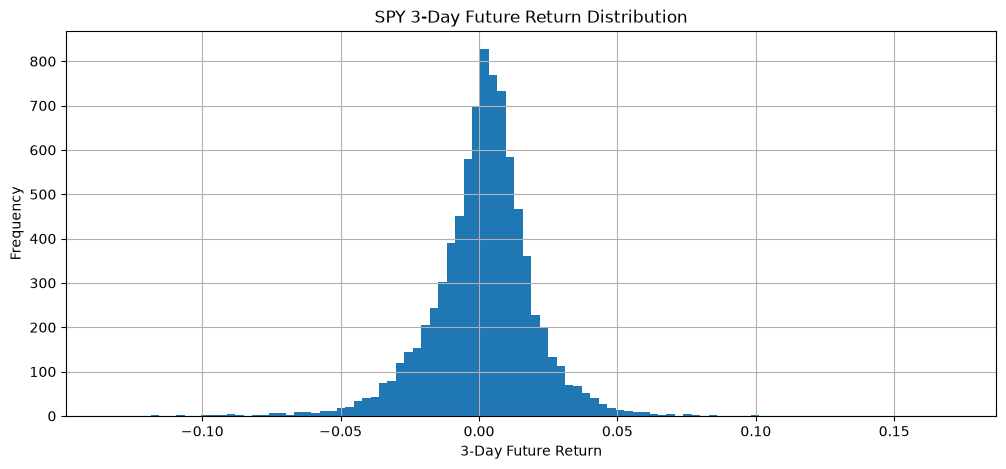

In [18]:
spy["future_return_3d"].hist(bins=100, figsize=(12, 5))
plt.title("SPY 3-Day Future Return Distribution")
plt.xlabel("3-Day Future Return")
plt.ylabel("Frequency")
plt.show()

In [19]:
spy["target_3d"] = np.nan

valid_target = spy["future_return_3d"].notna()

spy.loc[valid_target, "target_3d"] = (
    spy.loc[valid_target, "future_return_3d"] > 0.005
).astype(int)

In [20]:
spy[["Adj Close", "future_return_3d", "target_3d"]].tail(10)

Price,Adj Close,future_return_3d,target_3d
Ticker,SPY,,
Date,,,
2026-08-14,776.340027,-0.009377,0.0
2026-08-17,772.669983,-0.013033,0.0
2026-08-18,767.450012,-0.002254,0.0
2026-08-19,769.059998,-0.007269,0.0
2026-08-20,762.599976,0.004340,0.0
2026-08-21,765.719971,0.000470,0.0
2026-08-24,763.469971,0.011238,1.0
2026-08-25,765.909973,NaN,NaN


In [21]:
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

In [22]:
spy.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'return_1d',
       'future_return_3d', 'target_3d'],
      dtype='str', name='Price')

In [23]:
spy.columns.name

'Price'

In [24]:
spy.columns.name = None

In [25]:
spy.tail()

,Adj Close,Close,High,Low,Open,Volume,return_1d,future_return_3d,target_3d
Date,,,,,,,,,
2026-08-21,765.719971,765.719971,767.849976,764.169983,766.049988,39188700,0.004091,0.000470,0.0
2026-08-24,763.469971,763.469971,765.219971,762.080017,764.780029,32430900,-0.002938,0.011238,1.0
2026-08-25,765.909973,765.909973,766.780029,763.049988,766.159973,27422300,0.003196,NaN,NaN
2026-08-26,766.080017,766.080017,767.349976,763.929993,764.729980,28459700,0.000222,NaN,NaN
2026-08-27,772.049988,772.049988,772.354980,767.159973,768.500000,16175629,0.007793,NaN,NaN


In [26]:
spy.to_csv("../data/spy_market_data.csv")